## THEME EXTRACTION(RAKE + NOUN FREQUENCY + OPTIONAL LDA)

In [115]:
import pandas as pd
import numpy as np
import re
from langdetect import detect
from textblob import TextBlob
import nltk
import unicodedata
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from rake_nltk import Rake
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from gensim import corpora, models
import spacy
import matplotlib.pyplot as plt

In [116]:
df = pd.read_csv("scored_reviews.csv")

In [117]:
def rake_keywords(text, topk=5):
    try:
        r.extract_keywords_from_text(str(text))
        return r.get_ranked_phrases()[:topk]
    except:
        return []

In [118]:
df["rake_keywords"] = df["content_clean"].apply(rake_keywords)

In [119]:
def extract_nouns(text):
    try:
        doc = nlp(str(text))
        return [token.lemma_.lower() for token in doc if token.pos_ in ("NOUN","PROPN") and len(token.text)>2]
    except:
        return []

In [120]:
df["nouns"] = df["content_clean"].apply(extract_nouns)

In [121]:
common_nouns = {}
for bank in df["bank"].unique():
    all_nouns = sum(df[df["bank"]==bank]["nouns"].tolist(), [])
    top = Counter(all_nouns).most_common(25)
    common_nouns[bank] = top
    print(f"Top nouns for {bank}: {top[:10]}")

Top nouns for BOA: []
Top nouns for CBE: []
Top nouns for Dashen: []


In [122]:
def lda_topics(texts, num_topics=4, passes=5):
    # texts: list of token lists
    dictionary = corpora.Dictionary(texts)
    corpus = [dictionary.doc2bow(txt) for txt in texts]
    lda = models.LdaModel(corpus, num_topics=num_topics, id2word=dictionary, passes=passes)
    topics = lda.print_topics(num_words=5)
    return topics

In [123]:
token_lists = df["content"].apply(lambda t: t.split()).tolist()
try:
    topics = lda_topics(token_lists, num_topics=4)
    print("LDA topics:", topics)
    df.attrs["lda_topics"] = topics
except Exception as e:
    print("LDA failed:", e)

df.to_pickle("themes_reviews.pkl")
print("Saved themes_reviews.pkl")

LDA topics: [(0, '0.029*"and" + 0.028*"the" + 0.026*"to" + 0.024*"app" + 0.023*"is"'), (1, '0.031*"it" + 0.022*"is" + 0.018*"the" + 0.018*"to" + 0.018*"and"'), (2, '0.032*"the" + 0.029*"app" + 0.027*"and" + 0.025*"to" + 0.024*"is"'), (3, '0.011*"I" + 0.009*"always" + 0.009*"is" + 0.009*"." + 0.008*"a"')]
Saved themes_reviews.pkl


In [124]:
import pickle

In [125]:
theme_keywords = {
    "Technical Support": ["support", "help", "response", "staff", "service", "customer"],
    "Account & Transaction": ["transaction", "account", "transfer", "payment", "deposit", "withdraw", "balance", "money"],
    "User Interface Experience": ["ui", "interface", "design", "navigation", "layout", "easy", "simple", "confusing"],
    "Technical Issue": ["crash", "bugs", "slow", "error", "freeze", "glitch", "problem", "fail"]
} 

In [126]:
pos_reviews = df[df['sentiment_vader_label'] == 'positive']

In [127]:
df['bank'] = df['bank'].str.lower().str.strip()

In [128]:
theme_counts = {
    bank: {
        "Technical Support": 0,
        "Account & Transaction": 0,
        "User Interface Experience": 0,
        "Technical Issue": 0
    }
    for bank in df['bank'].unique()
}

In [129]:
for _, row in df.iterrows():
    bank = row['bank']   
    text = str(row['content_clean']).lower()

    for theme, keywords in theme_keywords.items():
        if any(k in text for k in keywords):
            theme_counts[bank][theme] += 1

In [130]:
print(theme_counts.keys())
print(df['bank'].unique())

dict_keys(['boa', 'cbe', 'dashen'])
['boa' 'cbe' 'dashen']


In [131]:
theme_counts = {bank: {theme:0 for theme in theme_keywords} for bank in pos_reviews['bank'].unique()}

for idx, row in pos_reviews.iterrows():
    bank = row['bank']
    review_text = row['content_clean'].lower()
    for theme, keywords in theme_keywords.items():
        if any(k in review_text for k in keywords):
            theme_counts[bank][theme] += 1
            theme_df = pd.DataFrame(theme_counts).T  
print(theme_df)

        Technical Support  Account & Transaction  User Interface Experience  \
BOA                     4                      6                          5   
CBE                     6                      7                          5   
Dashen                  8                     12                         30   

        Technical Issue  
BOA                   5  
CBE                   4  
Dashen                1  


In [132]:
print(theme_df.dtypes)

Technical Support            int64
Account & Transaction        int64
User Interface Experience    int64
Technical Issue              int64
dtype: object


In [133]:
theme_df = pd.DataFrame.from_dict(theme_counts, orient='index')
theme_df = theme_df.apply(pd.to_numeric)
print(theme_df.dtypes)
print(theme_df)

Technical Support            int64
Account & Transaction        int64
User Interface Experience    int64
Technical Issue              int64
dtype: object
        Technical Support  Account & Transaction  User Interface Experience  \
BOA                     4                      6                          5   
CBE                     6                      7                          5   
Dashen                  8                     12                         30   

        Technical Issue  
BOA                   5  
CBE                   4  
Dashen                1  


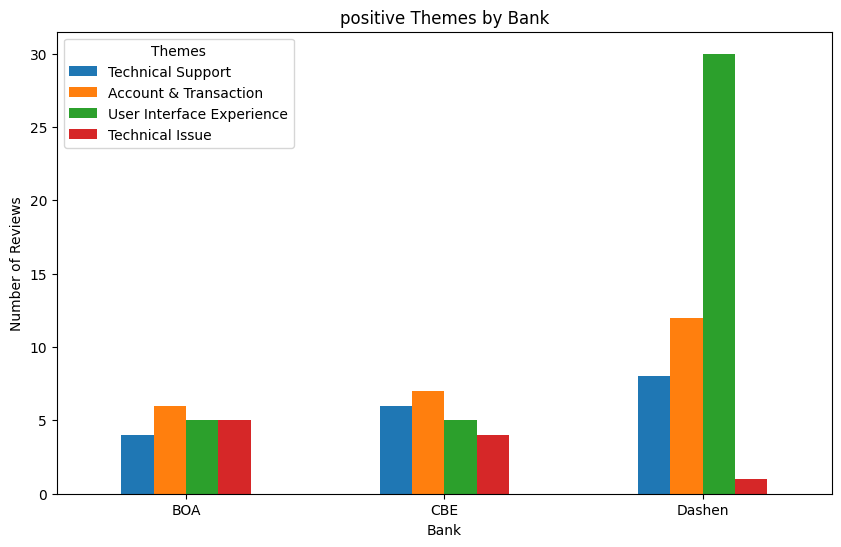

In [134]:
theme_df.plot(kind='bar', figsize=(10,6))
plt.title('positive Themes by Bank')
plt.ylabel('Number of Reviews')
plt.xlabel('Bank')
plt.xticks(rotation=0)
plt.legend(title='Themes')
plt.show()

In [135]:
neg_reviews = df[df['sentiment_vader_label'] == 'negative']

In [136]:
df['bank'] = df['bank'].str.lower().str.strip()

In [137]:
theme_counts = {
    bank: {
        "Technical Support": 0,
        "Account & Transaction": 0,
        "User Interface Experience": 0,
        "Technical Issue": 0
    }
    for bank in df['bank'].unique()
}

In [138]:
for _, row in df.iterrows():
    bank = row['bank']   
    text = str(row['content_clean']).lower()

    for theme, keywords in theme_keywords.items():
        if any(k in text for k in keywords):
            theme_counts[bank][theme] += 1

In [139]:
print(theme_counts.keys())
print(df['bank'].unique())

dict_keys(['boa', 'cbe', 'dashen'])
['boa' 'cbe' 'dashen']


In [140]:
theme_counts = {bank: {theme:0 for theme in theme_keywords} for bank in neg_reviews['bank'].unique()}

for idx, row in neg_reviews.iterrows():
    bank = row['bank']
    review_text = row['content_clean'].lower()
    for theme, keywords in theme_keywords.items():
        if any(k in review_text for k in keywords):
            theme_counts[bank][theme] += 1
            theme_df = pd.DataFrame(theme_counts).T  
print(theme_df)

        Technical Support  Account & Transaction  User Interface Experience  \
boa                     0                      2                          5   
cbe                     2                      3                          1   
dashen                  3                      7                          3   

        Technical Issue  
boa                  13  
cbe                   1  
dashen                6  


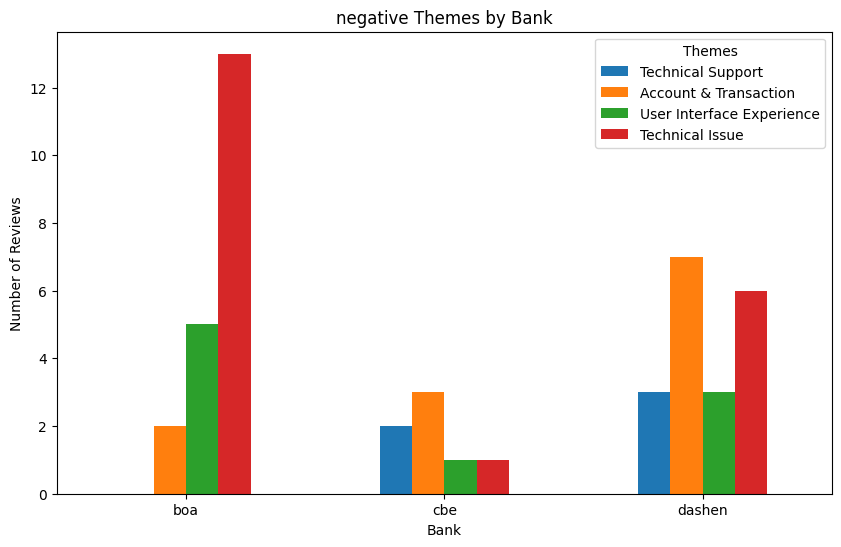

In [142]:
theme_df.plot(kind='bar', figsize=(10,6))
plt.title('negative Themes by Bank')
plt.ylabel('Number of Reviews')
plt.xlabel('Bank')
plt.xticks(rotation=0)
plt.legend(title='Themes')
plt.show()